In [2]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/perch_full.csv')

In [3]:
perch_full = df.to_numpy()
print(perch_full)

[[ 8.4   2.11  1.41]
 [13.7   3.53  2.  ]
 [15.    3.82  2.43]
 [16.2   4.59  2.63]
 [17.4   4.59  2.94]
 [18.    5.22  3.32]
 [18.7   5.2   3.12]
 [19.    5.64  3.05]
 [19.6   5.14  3.04]
 [20.    5.08  2.77]
 [21.    5.69  3.56]
 [21.    5.92  3.31]
 [21.    5.69  3.67]
 [21.3   6.38  3.53]
 [22.    6.11  3.41]
 [22.    5.64  3.52]
 [22.    6.11  3.52]
 [22.    5.88  3.52]
 [22.    5.52  4.  ]
 [22.5   5.86  3.62]
 [22.5   6.79  3.62]
 [22.7   5.95  3.63]
 [23.    5.22  3.63]
 [23.5   6.28  3.72]
 [24.    7.29  3.72]
 [24.    6.38  3.82]
 [24.6   6.73  4.17]
 [25.    6.44  3.68]
 [25.6   6.56  4.24]
 [26.5   7.17  4.14]
 [27.3   8.32  5.14]
 [27.5   7.17  4.34]
 [27.5   7.05  4.34]
 [27.5   7.28  4.57]
 [28.    7.82  4.2 ]
 [28.7   7.59  4.64]
 [30.    7.62  4.77]
 [32.8  10.03  6.02]
 [34.5  10.26  6.39]
 [35.   11.49  7.8 ]
 [36.5  10.88  6.86]
 [36.   10.61  6.74]
 [37.   10.84  6.26]
 [37.   10.57  6.37]
 [39.   11.14  7.49]
 [39.   11.14  6.  ]
 [39.   12.43  7.35]
 [40.   11.93

In [4]:
import numpy as np 

perch_weight = np.array([5.9, 32.0, 40.0, 51.5, 70.0, 100.0, 78.0, 80.0, 85.0, 85.0, 110.0,
       115.0, 125.0, 130.0, 120.0, 120.0, 130.0, 135.0, 110.0, 130.0,
       150.0, 145.0, 150.0, 170.0, 225.0, 145.0, 188.0, 180.0, 197.0,
       218.0, 300.0, 260.0, 265.0, 250.0, 250.0, 300.0, 320.0, 514.0,
       556.0, 840.0, 685.0, 700.0, 700.0, 690.0, 900.0, 650.0, 820.0,
       850.0, 900.0, 1015.0, 820.0, 1100.0, 1000.0, 1100.0, 1000.0,
       1000.0])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
  perch_full, perch_weight,
  random_state=42
)

In [ ]:
# n차식 다항식 생성 클래스
# 
from sklearn.preprocessing import PolynomialFeatures


poly = PolynomialFeatures()
poly.fit([[2, 3]])
# 절댓값, 2의 1승, 3의 1승, 2의 2승, 2*3, 3의 2승
print(poly.transform([[2, 3]]))

[[1. 2. 3. 4. 6. 9.]]


In [19]:

poly = PolynomialFeatures(include_bias=False)
poly.fit(X_train)
# 절댓값, 2의 1승, 3의 1승, 2의 2승, 2*3, 3의 2승
X_train_poly = poly.transform(X_train)
X_train_poly.shape

(42, 9)

In [20]:
poly.get_feature_names_out()

array(['x0', 'x1', 'x2', 'x0^2', 'x0 x1', 'x0 x2', 'x1^2', 'x1 x2',
       'x2^2'], dtype=object)

In [21]:
from sklearn.linear_model import LinearRegression

model = LinearRegression(tol=1e-14)
model.fit(X_train_poly, y_train)

X_test_poly = poly.transform(X_test)

print(f"train: {model.score(X_train_poly, y_train)}")
print(f"test: {model.score(X_test_poly, y_test)}")

train: 0.9903183436982126
test: 0.9714559911594125


In [22]:
poly = PolynomialFeatures(degree=5, include_bias=False)
X_train_poly = poly.fit_transform(X_train)

model = LinearRegression(tol=1e-14)

model.fit(X_train_poly, y_train)

X_test_poly = poly.transform(X_test)

print(f"train: {model.score(X_train_poly, y_train)}")
print(f"test: {model.score(X_test_poly, y_test)}")

train: 0.9999999999997232
test: -144.40564483377855


In [16]:
X_train_poly.shape

(42, 55)

In [23]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
ss.fit(X_train_poly)

X_train_scaled = ss.transform(X_train_poly)
X_test_scaled = ss.transform(X_test_poly)

In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)

ridge.score(X_test_scaled, y_test)

0.9790693977615387

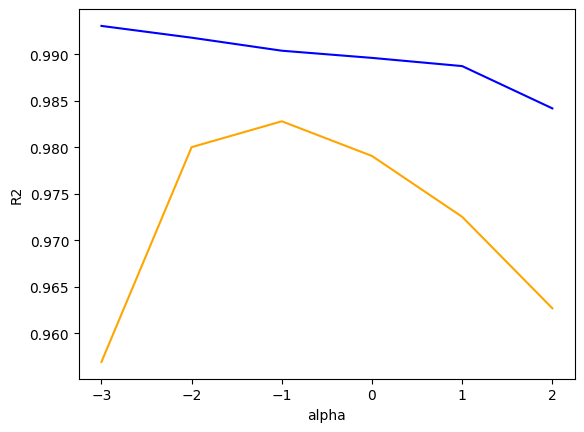

In [28]:
import matplotlib.pyplot as plt

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
  ridge = Ridge(alpha=alpha)
  ridge.fit(X_train_scaled, y_train)
  train_score.append(ridge.score(X_train_scaled, y_train))
  test_score.append(ridge.score(X_test_scaled, y_test))


plt.plot(np.log10(alpha_list), train_score, color="blue")
plt.plot(np.log10(alpha_list), test_score, color="orange")
plt.xlabel('alpha')
plt.ylabel('R2')
plt.show()

c:\Construction_Process_of_an_AI_Video_Object_Detection_and_Analysis_Platform_Utilizing_LangChain\workspace\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.877870e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(
c:\Construction_Process_of_an_AI_Video_Object_Detection_and_Analysis_Platform_Utilizing_LangChain\workspace\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.297282e+04, tolerance: 5.183e+02
  model = cd_fast.enet_coordinate_descent(


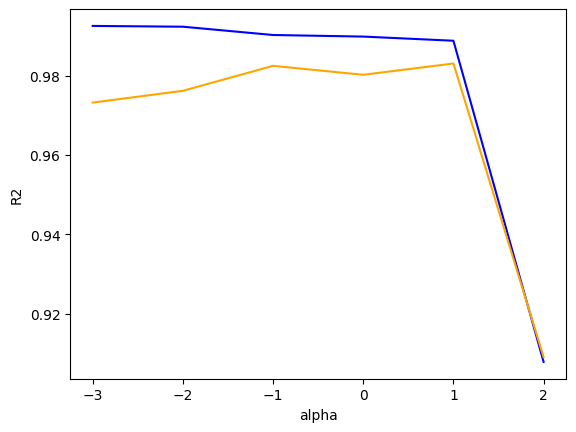

In [ ]:
from sklearn.linear_model import Lasso

train_score = []
test_score = []

alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]

for alpha in alpha_list:
  lasso = Lasso(alpha=alpha, max_iter=10000)
  lasso.fit(X_train_scaled, y_train)
  train_score.append(lasso.score(X_train_scaled, y_train))
  test_score.append(lasso.score(X_test_scaled, y_test))


plt.plot(np.log10(alpha_list), train_score, color="blue")
plt.plot(np.log10(alpha_list), test_score, color="orange")
plt.xlabel('alpha')
plt.ylabel('R2')
plt.show()